In [1]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *
import emcee
from functools import partial
import time

################################################################################
# 1) Create the disk_params dictionary (instead of DiskFlaherty object).
################################################################################
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

disk_params_mcmc = parametric_disk.create_disk_params(
    q=-0.23,
    q_in=-0.59,
    r_break=70.67,
    log_r_c=2.2,
    v_turb=0.42,
    T_atm1=56.41,
    gamma=1.0,
    T_mid1=21.86,
    M_star=2.3 * M_sun,
    r_in=11.16,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

In [5]:
################################################################################
# 2) Build the disk grid (z and r) for computing temperature, densities, etc.
################################################################################
resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

################################################################################
# 3) Use the functional approach to compute temperature, number density, velocity
################################################################################
temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)

nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)

velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_mcmc)

nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature_mcmc,
    disk_params_mcmc['gamma'],
    disk_params_mcmc['r_in'],
    10 ** disk_params_mcmc['log_r_c'],
    disk_params_mcmc['M_gas'],
    disk_params_mcmc['M_star'],
    disk_params_mcmc['m_mol']
)

velocity_az_mcmc = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2_mcmc, 
    temperature_mcmc, 
    disk_params_mcmc
)

################################################################################
# 4) Compute column density, CO abundance, etc. (still purely functional)
################################################################################
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)

abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2

abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params_mcmc)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

################################################################################
# 5) Prepare bounding box for interpolation
################################################################################
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])


In [6]:
################################################################################
# 6) Define the rendering functions in a functional style
################################################################################
def render_cube_pinhole(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    images = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

In [8]:
################################################################################
# 7) Example usage: generating pinhole and orthographic projections
################################################################################
# Pinhole Projection Setup
fov_as = 10.0  # arcsecs
# data_path = '~/code/radjax/data/alma/HD163296_CO_highres_cen.cm.fits'
data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_13CO_220GHz.0.2arcsec.image.fits'
velocity_range = (2000, 10000) # m/s
vlsr = 5770 # systematic velocity of target

data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)

# num_freqs_resample = 20
# num_freqs = len(data_cube.freqax)
# idx = np.round(np.linspace(0, num_freqs - 1, num_freqs_resample)).astype(int)

# data = data_cube.data[idx]
# freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)[idx]
# velocities = data_cube.velax[idx]

freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
velocities = data_cube.velax
data = data_cube.data

x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0  # e.g. 230.538 GHz
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
# if num_freqs_resample > 1:
#     delta_v_ms = velocities[1] - velocities[0]
# else: 
#     delta_v_ms = np.inf
print(f'velocity resolution: {delta_v_ms} m/s')

# Shift frequencies so that center is ~nu0
# freqs += nu0 - freqs.mean()

projection_pinhole = sensor.PinholeProjection(
    name='HD163296_13CO',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / npix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

beam = data_cube.beams_per_pix * sensor.beam(
    data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
)


velocity resolution: 199.99999999718648 m/s


In [9]:
data_cube.data.shape

(40, 502, 502)

In [10]:
################################################################################
# 8) Render the cubes via the new functional approach
################################################################################
images = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)
images_blurred = sensor.fftconvolve_vmap(images, beam)

images_mcmc = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params_mcmc,
    nd_co_mcmc,
    temperature_mcmc,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)
images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

computing pinhole spectral cube for a total of 40 frequencies
computing pinhole spectral cube for a total of 40 frequencies


In [11]:
residual_flaherty = images_blurred - data
chi2_flaherty = np.sum(((residual_flaherty) / 0.05)**2)
reduced_chi2_flaherty = chi2_flaherty / images_blurred.size
residual_sum_flaherty = np.sum(np.abs(residual_flaherty))
residual_mean_flaherty = np.mean(np.abs(residual_flaherty))

residual_mcmc = images_mcmc_blurred - data
chi2_mcmc = np.sum(((residual_mcmc) / 0.05)**2)
reduced_chi2_mcmc = chi2_mcmc / images_mcmc_blurred.size
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

residual_sum_flaherty, residual_sum_mcmc

(np.float64(25775.88864567489), np.float64(22101.88305112387))

NameError: name 'residual_mcmc' is not defined

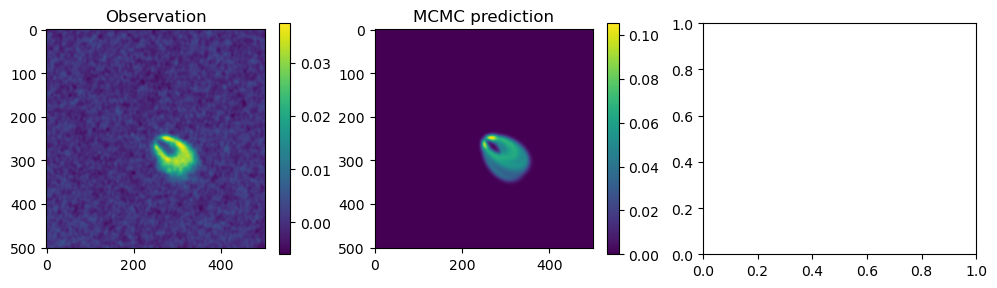

In [14]:
%matplotlib inline
img_index = 30
fig, axes = plt.subplots(1, 3, figsize=(12,3))

im0 = axes[0].imshow(data[img_index])
axes[0].set_title('Observation')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(images_mcmc_blurred[img_index])
axes[1].set_title('MCMC prediction')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(residual_mcmc[img_index])
axes[2].set_title('Residual (Truth - MCMC)')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [20]:
np.std(data[:,400:,:100])

np.float32(0.0014309003)

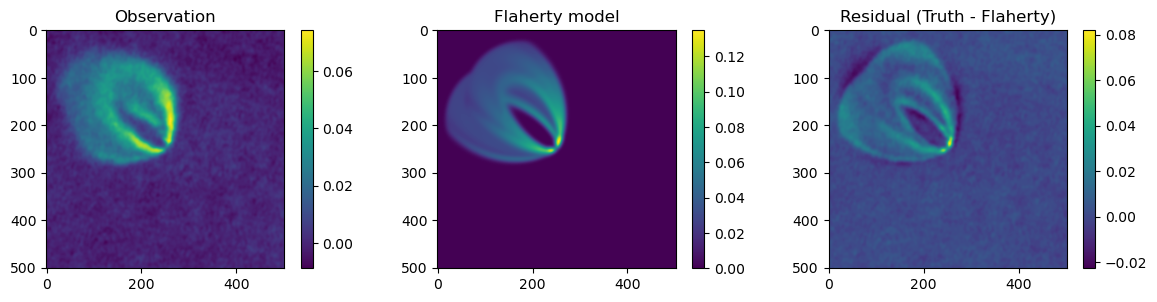

In [13]:
%matplotlib inline
img_index = 12
fig, axes = plt.subplots(1, 3, figsize=(12,3))

im0 = axes[0].imshow(data[img_index])
axes[0].set_title('Observation')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(images_blurred[img_index])
axes[1].set_title('Flaherty model')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(residual_flaherty[img_index])
axes[2].set_title('Residual (Truth - Flaherty)')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [14]:
###############################################################################
# 9) Convolve images with the beam
################################################################################

images_blurred = sensor.fftconvolve_vmap(images, beam)

noise = np.random.normal(0, noise_sigma * np.max(images), images.shape)
images_noisy = images + noise
images_noisy_blurred = sensor.fftconvolve_vmap(images_noisy, beam)

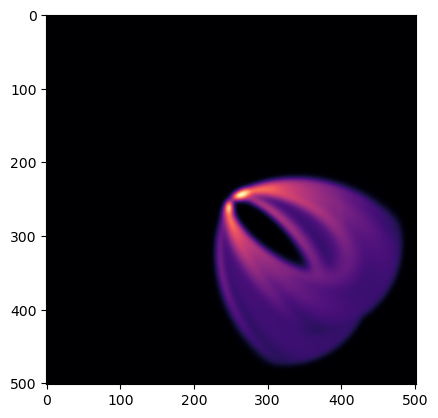

In [15]:
# Plotting Comparison
%matplotlib inline
image_index = 25
# Pinhole Projection Image
plt.imshow(images_blurred[image_index, :, :], cmap="magma")
# plt.savefig(f"projection_compare_{image_index}.png")
plt.show()

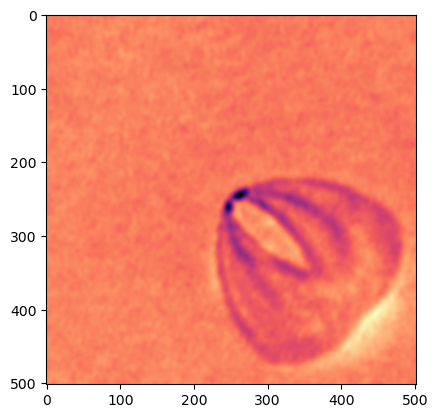

In [16]:
plt.imshow(data[image_index,:,:] - images_blurred[image_index, :, :], cmap="magma")

# Demo MCMC on high res CO data cube

In [26]:
import inference 

param_index_dict = inference.DISK_PARAM_INDEX
################################################################################
# 1) Set up the single-parameter prior for v_turb
################################################################################
posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.3, -0.1],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [2.00, 2.30],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.05, 0.15],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [60.0, 110.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [10.0, 30.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [5.0, 15.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [50.0, 80.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-0.7, -0.3],
    }
}

# Our disk_params dictionary (already created), e.g.:
disk_params = parametric_disk.create_disk_params(
    T_mid1=17.8,
    T_atm1=87.0,
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2.3,
    M_gas=0.09 * M_sun,
    v_turb=0.3,  # Just an initial guess; the MCMC will sample this
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

In [37]:
################################################################################
# 2) Create the sampler_dict for the new functional inference
################################################################################
sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=ray_coords_polar,
    obs_dir=obs_dir_pinhole,
    beam=beam,
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=0.007,
    disk_params=disk_params,
    posterior_params=posterior_params,
    stride=3
)


In [39]:
################################################################################
# 3) Initialize the walkers
################################################################################
ndim = len(list(posterior_params.keys()))    
nwalkers = 60
nsteps = 800 # Example number of MCMC steps
num_iter_restart = 80
restart_cluster_size = 1e-2

run_name = f"MAPS_CO_{nsteps}_iter_sigma7e-3_stride{sampler_dict['stride']}_MCMC_sampler.h5"

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)
run_name

'MAPS_CO_800_iter_sigma7e-3_stride3_MCMC_sampler.h5'

In [40]:
################################################################################
# 4) Set up and run the emcee MCMC
################################################################################

backend = emcee.backends.HDFBackend(run_name)
backend.reset(nwalkers, ndim)


def logprob_wrapper(params):
    """
    A small wrapper that calls the functional logprob with the 
    arguments we need: the data (images_ground_truth_blurred) 
    and frequencies, plus the sampler_dict.
    """
    return inference.logprob(params, data, freqs, sampler_dict)

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)


print("Running MCMC Warmup...")
warmup_sampler = sampler.run_mcmc(p0, num_iter_restart, progress=True)
flat_samples = sampler.get_chain(flat=True)
warmup_medians = np.median(flat_samples, axis=0)
p1 = np.random.normal(warmup_medians,  restart_cluster_size * np.abs(warmup_medians), size=(nwalkers, ndim))

print("Finished Warm up. Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))

print("Running MCMC:", np.mean(sampler.acceptance_fraction))
start_time_mcmc = time.time()
sampler.run_mcmc(p1, nsteps, progress=True)
end_time_mcmc = time.time()
mcmc_time = end_time_mcmc - start_time_mcmc
print(f"MCMC completed in {mcmc_time:.2f} seconds.")
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))

Running MCMC Warmup...


100%|█| 80/80 [1:10:14<00:00


Finished Warm up. Mean acceptance fraction: 0.29124999999999995
Running MCMC: 0.29124999999999995


100%|█| 800/800 [11:42:52<00

MCMC completed in 42224.94 seconds.
Mean acceptance fraction: 0.10954545454545456


In [54]:
sampler.get_chain(flat=True)

array([[ 1.52404935e+01,  7.70467986e+01, -2.80710003e-01, ...,
         1.46970407e+01,  2.13117120e+00,  7.73092427e-02],
       [ 1.31736794e+01,  9.61428809e+01, -2.92554026e-01, ...,
         6.22535137e+00,  2.12994244e+00,  5.85941967e-02],
       [ 1.79502418e+01,  6.82439999e+01, -2.24887767e-01, ...,
         8.58086048e+00,  2.06298135e+00,  1.42560420e-01],
       ...,
       [ 1.80821883e+01,  6.24594771e+01, -1.92661193e-01, ...,
         1.99971410e+01,  2.21535752e+00,  3.95109927e-01],
       [ 1.81415482e+01,  6.21352309e+01, -1.92686647e-01, ...,
         1.98865482e+01,  2.21501405e+00,  3.96760481e-01],
       [ 1.89814219e+01,  6.00912839e+01, -1.86744331e-01, ...,
         1.97738187e+01,  2.19118107e+00,  4.09052081e-01]])

In [64]:
sampler_load = emcee.backends.HDFBackend(run_name)

################################################################################
# 6) Update the disk_params with the MCMC result and re-render
################################################################################
samples = sampler_load.get_chain(flat=True)

flat_samples = sampler_load.get_chain(discard=nsteps//2, thin=1, flat=True)

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]


chosen_values = np.median(flat_samples, axis=0)
print("Chosen parameter values (from MCMC) with their Flaherty's values:")

for label, value in zip(param_labels, chosen_values):
    disk_params[label] = value
    print(f"{label}: chosen value = {value:.4f}")
    

# Recompute temperature and densities with updated v_turb
temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)
nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk,
    r_disk,
    temperature_mcmc,
    disk_params["gamma"],
    disk_params["r_in"],
    10 ** disk_params["log_r_c"],
    disk_params["M_gas"],
    disk_params["M_star"],
    disk_params["m_mol"]
)

velocity_az_mcmc = -parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_mcmc, temperature_mcmc, disk_params
)

N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)
abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

# Render new cube with the updated v_turb
images_mcmc = render_cube_pinhole(
    ray_coords=ray_coords_pinhole,
    pixel_area=pixel_area_pinhole,
    disk_params=disk_params,       # pass the dictionary instead of a disk object
    nd_co=nd_co_mcmc,
    temperature=temperature_mcmc,
    velocity_az=velocity_az_mcmc,
    bbox=bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

residual_mcmc = images_noisy_blurred - images_mcmc_blurred
chi2_mcmc = np.sum(((images_noisy_blurred - images_mcmc_blurred) / 0.05)**2)
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

n_data = np.prod(data.shape)
chi_squared_over_n_data = chi2_mcmc / n_data

print(f"MCMC Chi-squared: {chi2_mcmc:.2f}, Chi-squared/N_data = {chi_squared_over_n_data}")
print(f"MCMC Residual Sum: {residual_sum_mcmc:.5f}")
print(f"MCMC Residual Mean: {residual_mean_mcmc:.5f}")

Chosen parameter values (from MCMC) with their Flaherty's values:
T_mid1: chosen value = 17.9564
T_atm1: chosen value = 62.5634
q: chosen value = -0.1926
q_in: chosen value = -0.4058
r_break: chosen value = 105.7232
r_in: chosen value = 19.8141
log_r_c: chosen value = 2.2165
v_turb: chosen value = 0.3900
computing pinhole spectral cube for a total of 40 frequencies
MCMC Chi-squared: 102802.76, Chi-squared/N_data = 0.010198524665250864
MCMC Residual Sum: 28257.87513
MCMC Residual Mean: 0.00280


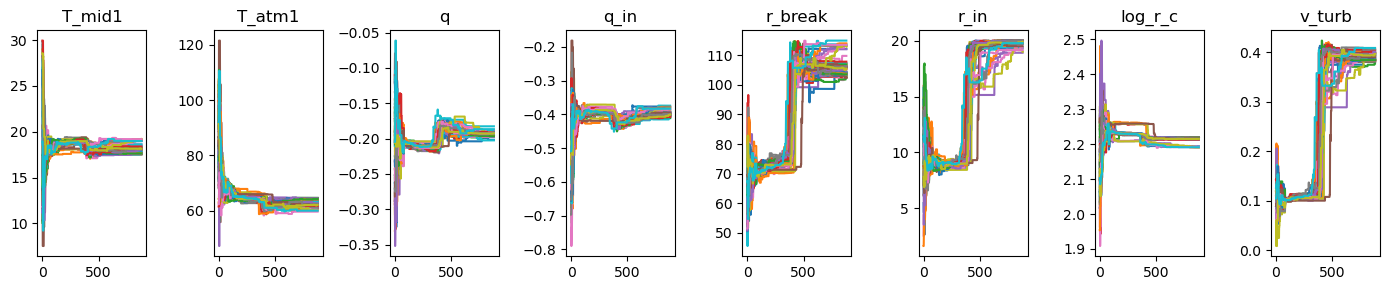

In [65]:
chain = sampler_load.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

Flat samples shape: (22800, 8)


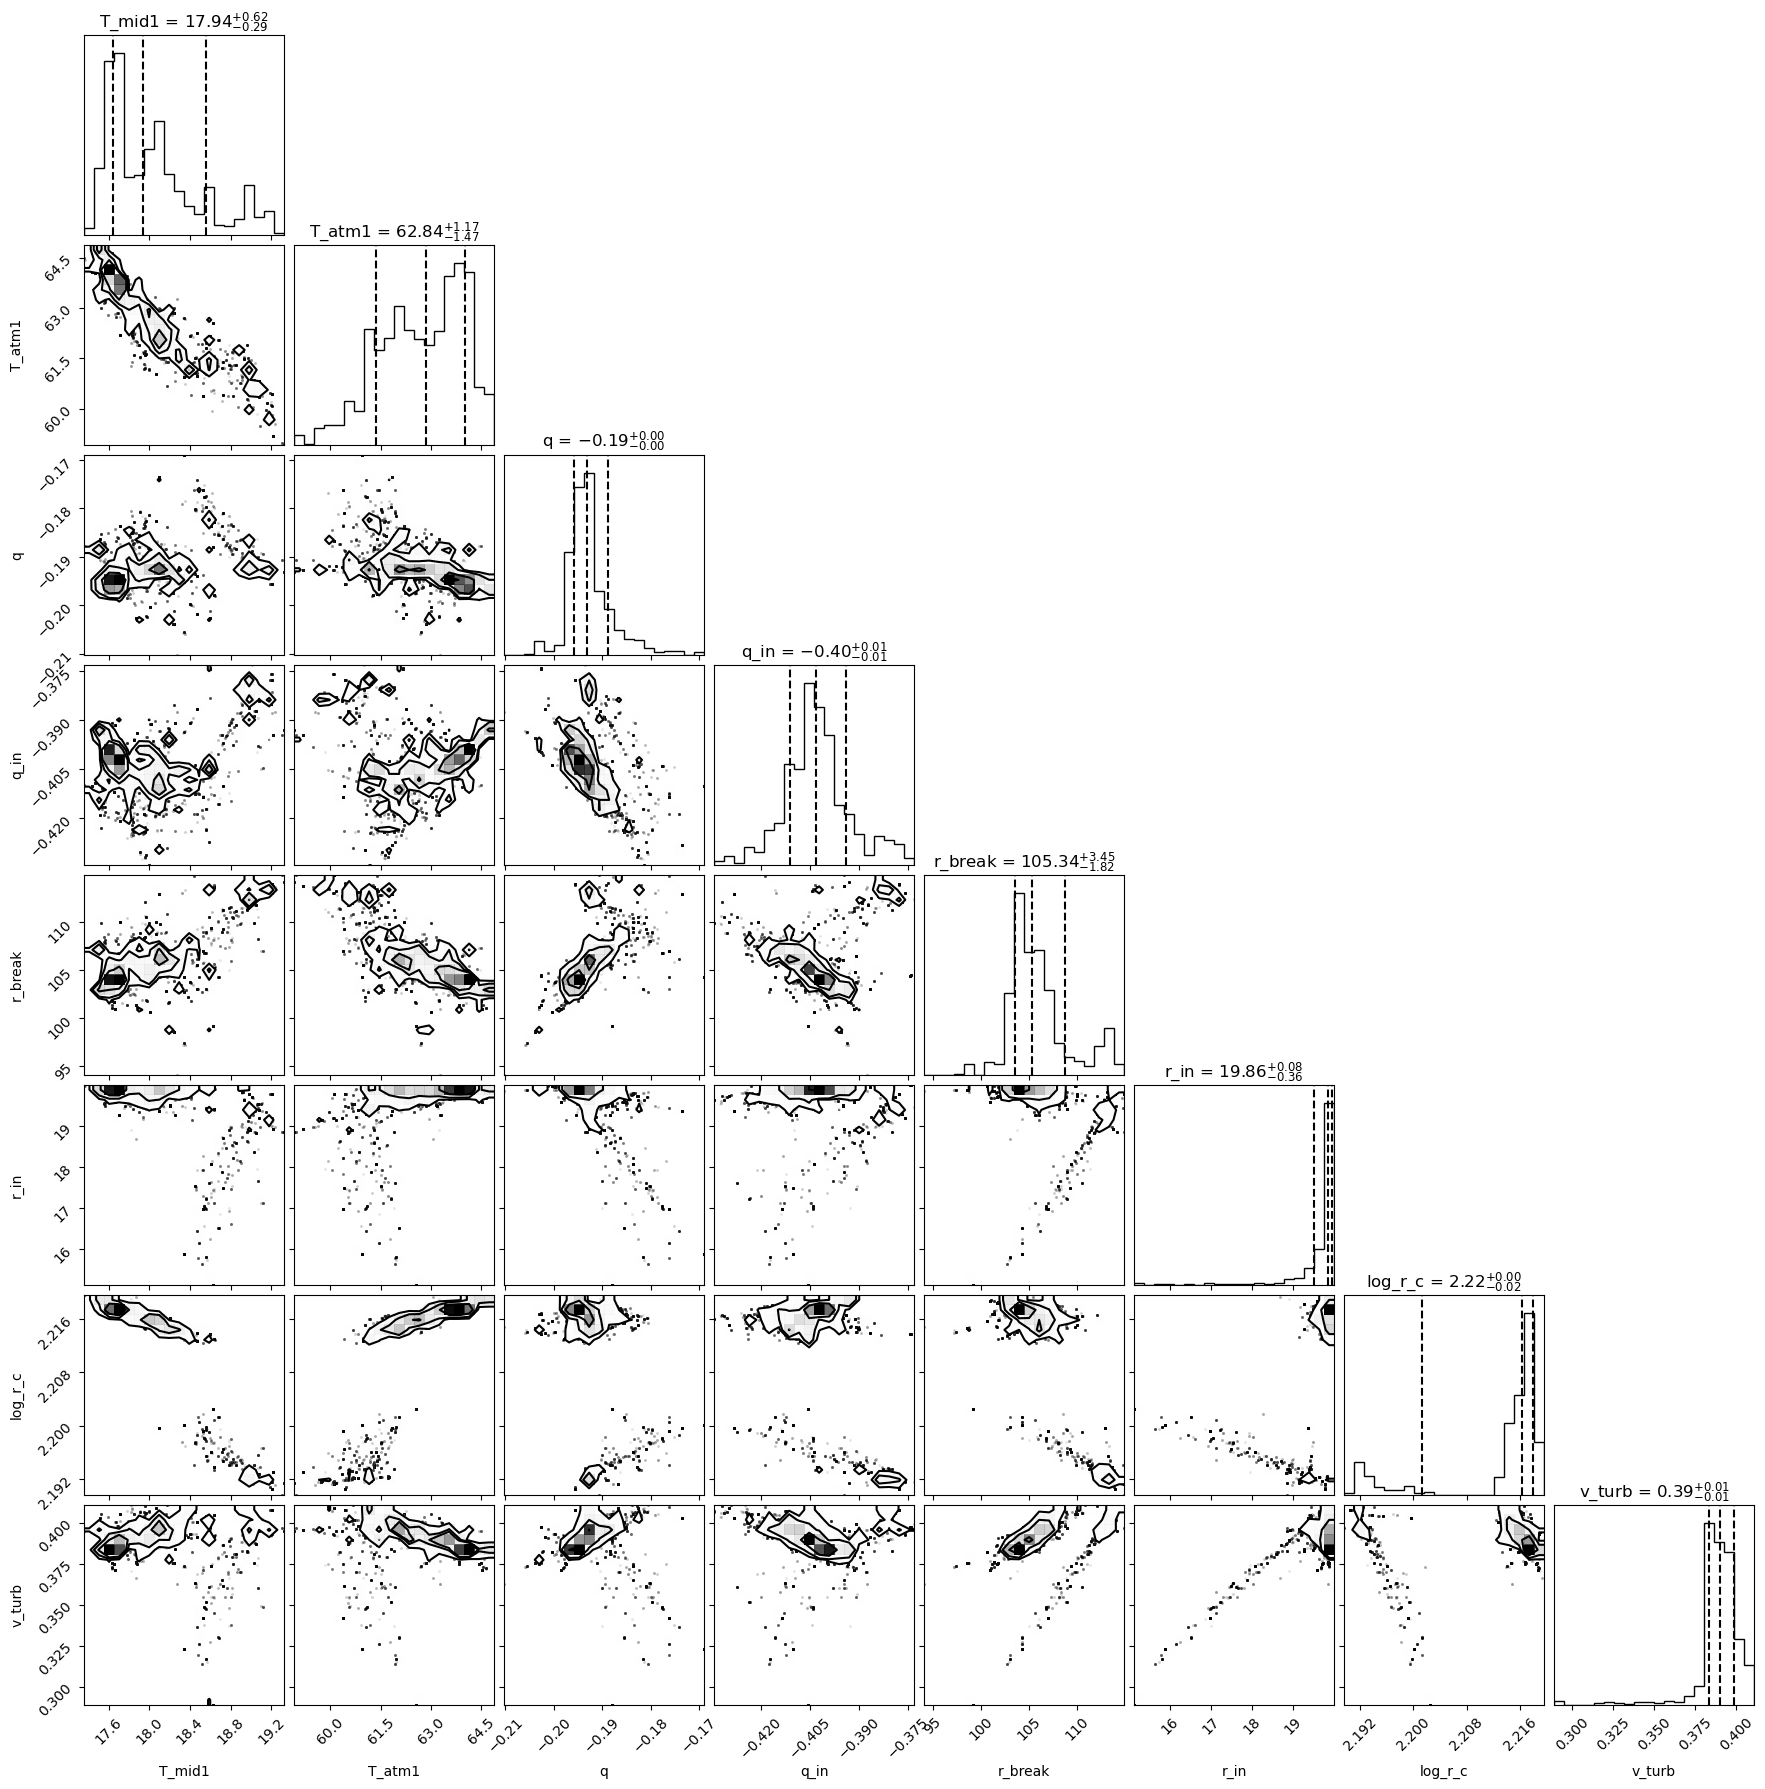

In [66]:
%matplotlib inline
import corner

# Discard first 100 steps, flatten the rest
flat_samples = sampler_load.get_chain(discard=500, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)

In [68]:
for i, label in enumerate(param_labels):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    median_val = p50
    minus_err = p50 - p16
    plus_err  = p84 - p50
    print(f"{label:8s}: {median_val:.3f} +{plus_err:.3f} -{minus_err:.3f}")

T_mid1  : 17.938 +0.617 -0.295
T_atm1  : 62.838 +1.166 -1.475
q       : -0.193 +0.004 -0.003
q_in    : -0.403 +0.009 -0.008
r_break : 105.337 +3.452 -1.816
r_in    : 19.861 +0.083 -0.360
log_r_c : 2.216 +0.002 -0.015
v_turb  : 0.390 +0.009 -0.007


In [69]:
disk_params_alt = parametric_disk.create_disk_params(
    q        = -0.193,                
    q_in     = -0.403,                
    r_break  = 105.337,                
    log_r_c  = 2.216,                 
    v_turb   = 0.390,                  
    T_mid1   = 17.942,               
    T_atm1   = 85.029,                 
    gamma    = 1.0,
    M_star   = 2.3 * M_sun,
    r_in     = 19.861,                 
    M_gas    = 0.09 * M_sun,
    co_abundance = 1e-4,
    N_dissoc     = 0.79 * 1.59e21,
    N_desorp     = -np.inf,
    freezeout    = 19.0,
    r_scale      = 150.0,
    z_q0         = 70.0,
    delta        = 1,
    transition   = 2,
    m_mol        = 2.37 * m_h,
)

temperature_alt = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_alt)

nd_h2_alt = parametric_disk.number_density_profile(
    z_disk, r_disk, temperature_alt,
    disk_params_alt['gamma'],
    disk_params_alt['r_in'],
    10**disk_params_alt['log_r_c'],
    disk_params_alt['M_gas'],
    disk_params_alt['M_star'],
    disk_params_alt['m_mol']
)

velocity_az_alt = parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_alt, temperature_alt, disk_params_alt
)

N_h2_alt = parametric_disk.surface_density(z_disk, nd_h2_alt)
abundance_co_alt = parametric_disk.co_abundance_profile(N_h2_alt, temperature_alt, disk_params_alt)
nd_co_alt = abundance_co_alt * nd_h2_alt

images_mcmc_img = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params_alt,
    nd_co_alt,
    temperature_alt,
    -velocity_az_alt,    # note the same sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_img_blurred = sensor.fftconvolve_vmap(images_mcmc_img, beam)

computing pinhole spectral cube for a total of 40 frequencies


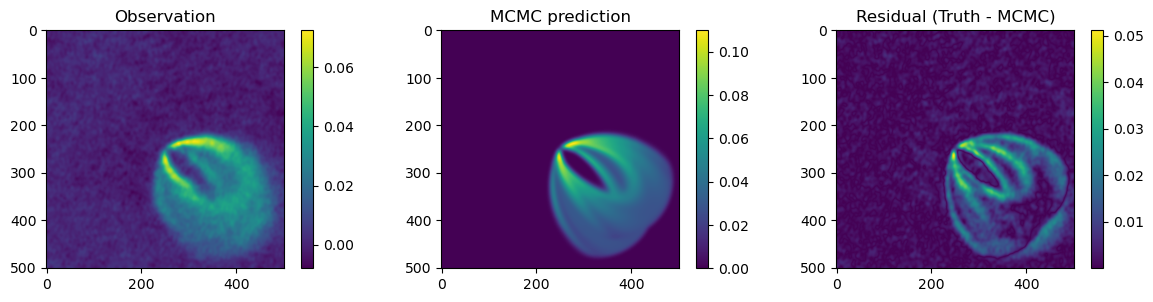

In [75]:
%matplotlib inline
img_index = 25
fig, axes = plt.subplots(1, 3, figsize=(12,3))

residual_mcmc = np.abs(data - images_mcmc_img_blurred)

im0 = axes[0].imshow(data[img_index])
axes[0].set_title('Observation')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(images_mcmc_img_blurred[img_index])
axes[1].set_title('MCMC prediction')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(residual_mcmc[img_index])
axes[2].set_title('Residual (Truth - MCMC)')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [73]:
np.mean(residual_mcmc)

np.float64(0.002655758109895512)